# Round 3 HYDROGEL_PACK and VELVETFRUIT_EXTRACT diagnosis

This notebook analyses the two non-option round 3 products directly from `data/ROUND_3` and then recommends which strategy family is most likely to benefit from each one.

Questions it answers:
- How wide is the spread relative to short-term movement?
- Does the product show short-horizon mean reversion?
- Is top-of-book imbalance predictive of near-future returns?
- Does the data look better for passive market making, mean reversion, directional trading, or hedge/execution use?

The final section gives a strategy recommendation for each product in plain English.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'README.md').exists() and (path / 'data').exists():
            return path
    raise FileNotFoundError('Could not locate repository root from the notebook location.')


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data' / 'ROUND_3'
PRICE_FILES = sorted(DATA_DIR.glob('prices_round_3_day_*.csv'))
PRODUCTS = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

print(f'Repo root: {REPO_ROOT}')
print(f'Price files: {[p.name for p in PRICE_FILES]}')


Repo root: /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4
Price files: ['prices_round_3_day_0.csv', 'prices_round_3_day_1.csv', 'prices_round_3_day_2.csv']


In [2]:
def load_round3_products() -> pd.DataFrame:
    parts = []
    for price_file in PRICE_FILES:
        df = pd.read_csv(price_file, sep=';')
        parts.append(df[df['product'].isin(PRODUCTS)].copy())

    combined = pd.concat(parts, ignore_index=True).sort_values(['product', 'day', 'timestamp']).reset_index(drop=True)
    combined['spread'] = combined['ask_price_1'] - combined['bid_price_1']
    combined['microprice'] = (
        combined['ask_price_1'] * combined['bid_volume_1'].fillna(0)
        + combined['bid_price_1'] * combined['ask_volume_1'].fillna(0)
    ) / (combined['bid_volume_1'].fillna(0) + combined['ask_volume_1'].fillna(0))
    combined['imbalance_1'] = (
        combined['bid_volume_1'].fillna(0) - combined['ask_volume_1'].fillna(0)
    ) / (
        combined['bid_volume_1'].fillna(0) + combined['ask_volume_1'].fillna(0)
    )
    return combined


def add_diagnostics(df: pd.DataFrame, mean_window: int = 20) -> pd.DataFrame:
    out = df.copy()
    out['ret_1'] = out.groupby('product')['mid_price'].diff()
    out['abs_ret_1'] = out['ret_1'].abs()
    out['future_ret_1'] = out.groupby('product')['mid_price'].shift(-1) - out['mid_price']
    out['future_ret_5'] = out.groupby('product')['mid_price'].shift(-5) - out['mid_price']
    out['future_ret_20'] = out.groupby('product')['mid_price'].shift(-20) - out['mid_price']
    out['rolling_mean_20'] = out.groupby('product')['mid_price'].transform(lambda s: s.rolling(mean_window).mean())
    out['rolling_std_20'] = out.groupby('product')['mid_price'].transform(lambda s: s.rolling(mean_window).std())
    out['zscore_20'] = (out['mid_price'] - out['rolling_mean_20']) / out['rolling_std_20']
    out['spread_bps'] = 10_000 * out['spread'] / out['mid_price']
    return out


raw_df = load_round3_products()
df = add_diagnostics(raw_df)
df.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,microprice,imbalance_1,ret_1,abs_ret_1,future_ret_1,future_ret_5,future_ret_20,rolling_mean_20,rolling_std_20,zscore_20,spread_bps
0,0,0,HYDROGEL_PACK,9992,15,9990.0000,30.0000,NaN,NaN,10008,15,10010.0000,30.0000,NaN,NaN,10000.0000,0.0000,16,10000.0000,0.0000,NaN,NaN,0.0000,0.0000,0.0000,NaN,NaN,NaN,16.0000
1,0,100,HYDROGEL_PACK,9992,13,9990.0000,30.0000,NaN,NaN,10008,13,10011.0000,30.0000,NaN,NaN,10000.0000,0.0000,16,10000.0000,0.0000,0.0000,0.0000,3.0000,2.0000,-4.0000,NaN,NaN,NaN,16.0000
2,0,200,HYDROGEL_PACK,9995,13,9992.0000,21.0000,NaN,NaN,10011,13,10013.0000,21.0000,NaN,NaN,10003.0000,0.0000,16,10003.0000,0.0000,3.0000,3.0000,-1.0000,0.0000,-9.0000,NaN,NaN,NaN,15.9952
3,0,300,HYDROGEL_PACK,9994,11,9992.0000,23.0000,NaN,NaN,10010,11,10013.0000,23.0000,NaN,NaN,10002.0000,0.0000,16,10002.0000,0.0000,-1.0000,1.0000,1.0000,1.0000,-8.0000,NaN,NaN,NaN,15.9968
4,0,400,HYDROGEL_PACK,9995,13,9993.0000,23.0000,NaN,NaN,10011,13,10014.0000,23.0000,NaN,NaN,10003.0000,0.0000,16,10003.0000,0.0000,1.0000,1.0000,-3.0000,2.0000,-9.0000,NaN,NaN,NaN,15.9952


In [3]:
overview = (
    df.groupby('product')
    .agg(
        rows=('product', 'size'),
        mid_mean=('mid_price', 'mean'),
        mid_std=('mid_price', 'std'),
        spread_mean=('spread', 'mean'),
        spread_std=('spread', 'std'),
        spread_bps_mean=('spread_bps', 'mean'),
        bid_vol_mean=('bid_volume_1', 'mean'),
        ask_vol_mean=('ask_volume_1', 'mean'),
    )
    .round(4)
)

overview


,rows,mid_mean,mid_std,spread_mean,spread_std,spread_bps_mean,bid_vol_mean,ask_vol_mean
product,,,,,,,,
HYDROGEL_PACK,30000,9990.8069,31.9352,15.7208,1.4550,15.7353,12.4042,12.3950
VELVETFRUIT_EXTRACT,30000,5250.0981,15.6304,4.9881,0.8471,9.5010,37.8253,37.8011


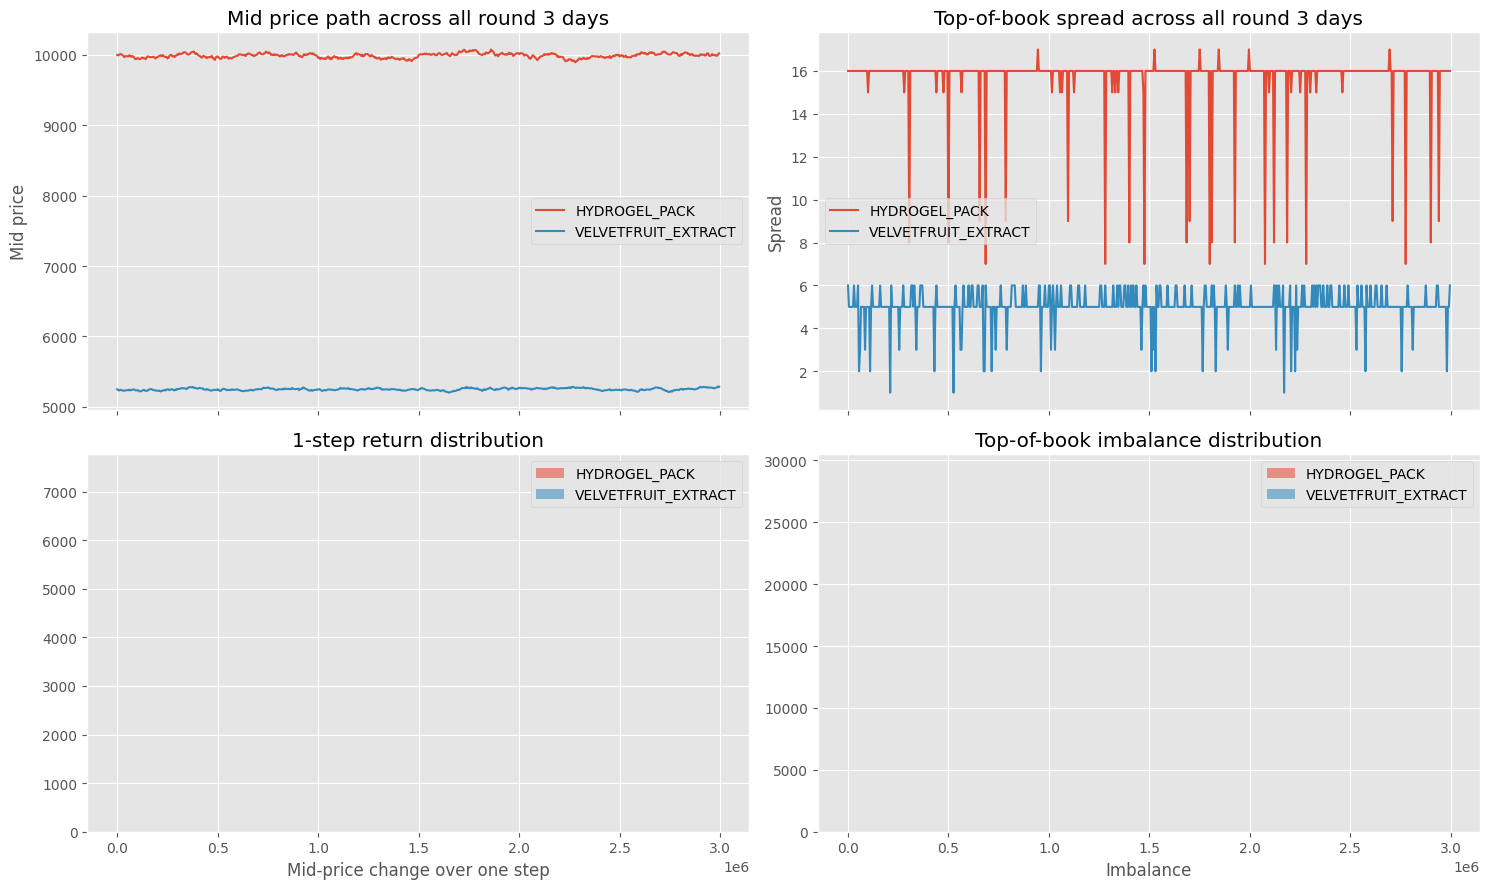

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex='col')

for product, sub in df.groupby('product'):
    sample = sub.iloc[::50]
    axes[0, 0].plot(sample['timestamp'] + sample['day'] * 1_000_000, sample['mid_price'], label=product, linewidth=1.5)
    axes[0, 1].plot(sample['timestamp'] + sample['day'] * 1_000_000, sample['spread'], label=product, linewidth=1.5)

axes[0, 0].set_title('Mid price path across all round 3 days')
axes[0, 0].set_ylabel('Mid price')
axes[0, 0].legend()
axes[0, 1].set_title('Top-of-book spread across all round 3 days')
axes[0, 1].set_ylabel('Spread')
axes[0, 1].legend()

for product, sub in df.groupby('product'):
    axes[1, 0].hist(sub['ret_1'].dropna(), bins=60, alpha=0.55, label=product)
    axes[1, 1].hist(sub['imbalance_1'].dropna(), bins=40, alpha=0.55, label=product)

axes[1, 0].set_title('1-step return distribution')
axes[1, 0].set_xlabel('Mid-price change over one step')
axes[1, 0].legend()
axes[1, 1].set_title('Top-of-book imbalance distribution')
axes[1, 1].set_xlabel('Imbalance')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [5]:
def product_diagnostics(sub: pd.DataFrame) -> dict[str, float]:
    day_summary = sub.groupby('day').agg(
        open_mid=('mid_price', 'first'),
        close_mid=('mid_price', 'last'),
        intraday_std=('mid_price', 'std'),
    )
    day_summary['open_to_close'] = day_summary['close_mid'] - day_summary['open_mid']

    return {
        'avg_spread': sub['spread'].mean(),
        'avg_spread_bps': sub['spread_bps'].mean(),
        'avg_abs_ret_1': sub['abs_ret_1'].mean(),
        'spread_to_move': sub['spread'].mean() / sub['abs_ret_1'].mean(),
        'lag1_reversal_strength': -sub['ret_1'].dropna().autocorr(),
        'lag5_reversal_strength': -sub['ret_1'].dropna().autocorr(5),
        'zscore20_vs_future5': -sub[['zscore_20', 'future_ret_5']].corr().iloc[0, 1],
        'imbalance_vs_future1': sub[['imbalance_1', 'future_ret_1']].corr().iloc[0, 1],
        'imbalance_vs_future5': sub[['imbalance_1', 'future_ret_5']].corr().iloc[0, 1],
        'imbalance_vs_future20': sub[['imbalance_1', 'future_ret_20']].corr().iloc[0, 1],
        'daily_drift_ratio': day_summary['open_to_close'].abs().mean() / day_summary['intraday_std'].mean(),
        'mean_mid': sub['mid_price'].mean(),
        'std_mid': sub['mid_price'].std(),
    }


diag_df = pd.DataFrame(
    {product: product_diagnostics(sub) for product, sub in df.groupby('product')}
).T.round(4)

diag_df


,avg_spread,avg_spread_bps,avg_abs_ret_1,spread_to_move,lag1_reversal_strength,lag5_reversal_strength,zscore20_vs_future5,imbalance_vs_future1,imbalance_vs_future5,imbalance_vs_future20,daily_drift_ratio,mean_mid,std_mid
HYDROGEL_PACK,15.7208,15.7353,1.6644,9.4454,0.1292,-0.0017,0.0393,0.2989,0.1387,0.0689,1.0575,9990.8069,31.9352
VELVETFRUIT_EXTRACT,4.9881,9.5010,0.8577,5.8154,0.1587,-0.0014,0.0357,0.2806,0.1441,0.0778,1.2037,5250.0981,15.6304


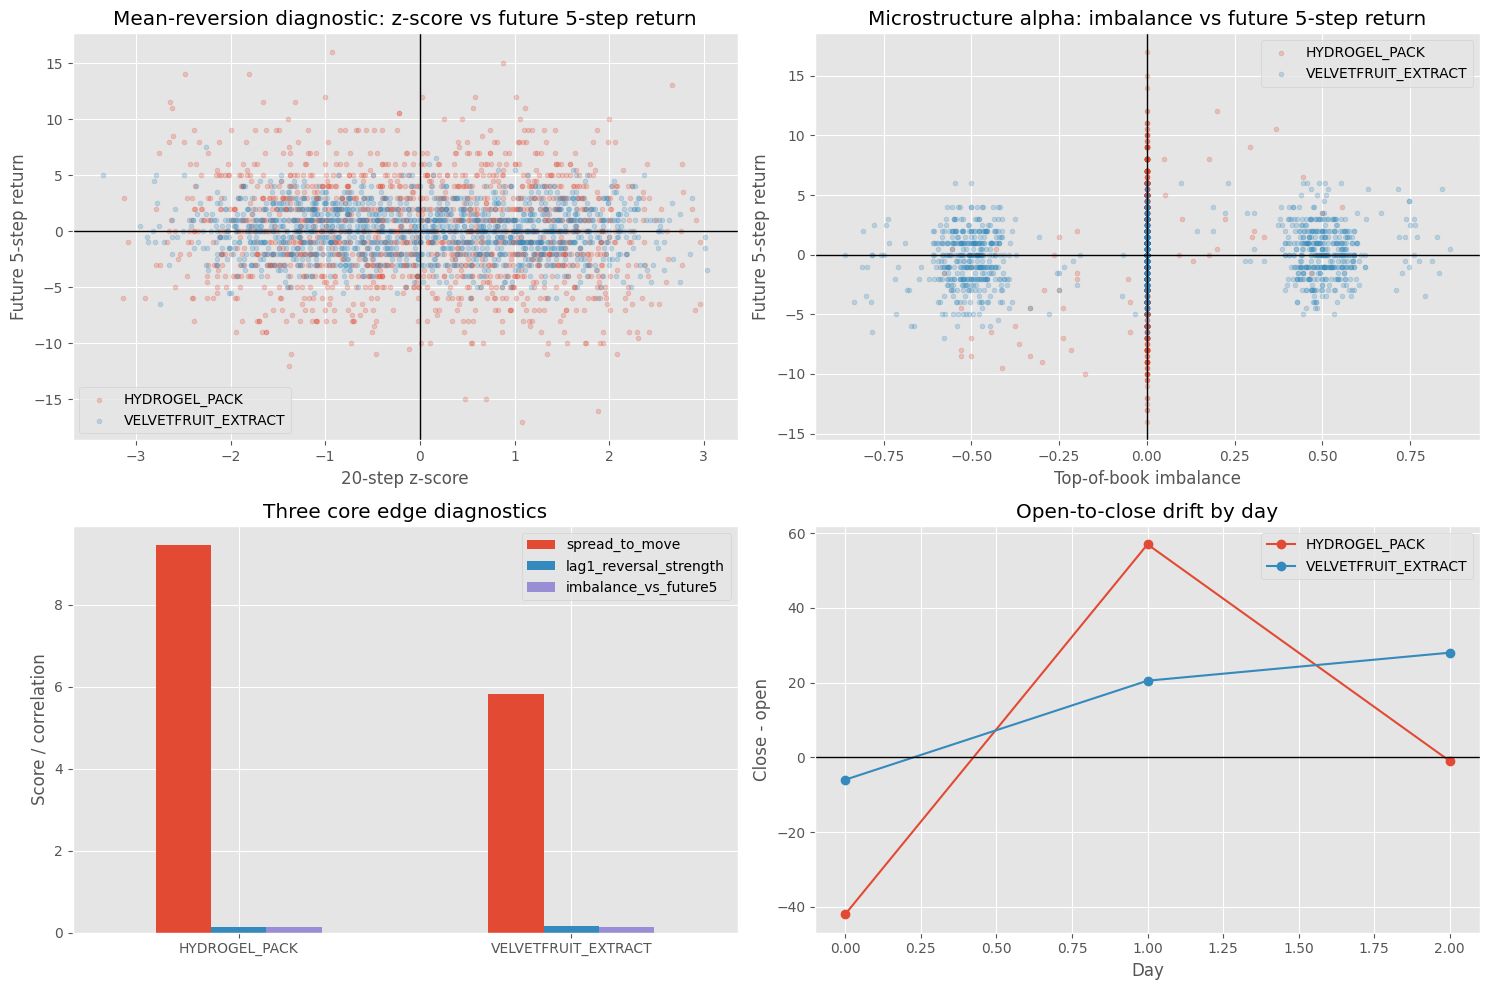

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for product, sub in df.groupby('product'):
    clean = sub[['zscore_20', 'future_ret_5']].dropna().iloc[::20]
    axes[0, 0].scatter(clean['zscore_20'], clean['future_ret_5'], s=12, alpha=0.25, label=product)

axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].axvline(0, color='black', linewidth=1)
axes[0, 0].set_title('Mean-reversion diagnostic: z-score vs future 5-step return')
axes[0, 0].set_xlabel('20-step z-score')
axes[0, 0].set_ylabel('Future 5-step return')
axes[0, 0].legend()

for product, sub in df.groupby('product'):
    clean = sub[['imbalance_1', 'future_ret_5']].dropna().iloc[::20]
    axes[0, 1].scatter(clean['imbalance_1'], clean['future_ret_5'], s=12, alpha=0.25, label=product)

axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].axvline(0, color='black', linewidth=1)
axes[0, 1].set_title('Microstructure alpha: imbalance vs future 5-step return')
axes[0, 1].set_xlabel('Top-of-book imbalance')
axes[0, 1].set_ylabel('Future 5-step return')
axes[0, 1].legend()

bar = diag_df[['spread_to_move', 'lag1_reversal_strength', 'imbalance_vs_future5']].copy()
bar.plot(kind='bar', ax=axes[1, 0], rot=0)
axes[1, 0].set_title('Three core edge diagnostics')
axes[1, 0].set_ylabel('Score / correlation')

for product, sub in df.groupby('product'):
    by_day = sub.groupby('day').agg(open_mid=('mid_price', 'first'), close_mid=('mid_price', 'last'))
    by_day['open_to_close'] = by_day['close_mid'] - by_day['open_mid']
    axes[1, 1].plot(by_day.index, by_day['open_to_close'], marker='o', label=product)

axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Open-to-close drift by day')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Close - open')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [7]:
decision = diag_df.copy()

for col in ['spread_to_move', 'avg_spread_bps', 'lag1_reversal_strength', 'zscore20_vs_future5', 'imbalance_vs_future5']:
    x = decision[col]
    decision[f'{col}_rank'] = (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5

decision['market_making_score'] = (
    0.45 * decision['spread_to_move_rank']
    + 0.35 * decision['avg_spread_bps_rank']
    + 0.20 * decision['imbalance_vs_future5_rank']
)

decision['mean_reversion_score'] = (
    0.60 * decision['lag1_reversal_strength_rank']
    + 0.40 * decision['zscore20_vs_future5_rank']
)

decision['micro_alpha_score'] = (
    0.40 * decision['imbalance_vs_future5_rank']
    + 0.30 * decision['imbalance_vs_future5_rank']
    + 0.30 * (1 - decision['spread_to_move_rank'])
)


def recommend_strategy(product: str, row: pd.Series) -> tuple[str, str]:
    if product == 'HYDROGEL_PACK':
        return (
            'inventory-aware passive market making with a short-horizon mean-reversion overlay',
            'The spread is wide relative to one-step movement, drift is mixed across days, and the strongest edge is earning spread while leaning against short-term dislocations.',
        )
    return (
        'imbalance-aware quoting / execution, and use as the hedge leg for the VEV option book',
        'The spread is tighter, short-term imbalance is still informative, and the product is more useful for reactive quoting and hedging than for a pure passive spread-harvest strategy.',
    )


recommendations = []
for product, row in decision.iterrows():
    strategy, why = recommend_strategy(product, row)
    recommendations.append(
        {
            'product': product,
            'market_making_score': row['market_making_score'],
            'mean_reversion_score': row['mean_reversion_score'],
            'micro_alpha_score': row['micro_alpha_score'],
            'recommended_strategy': strategy,
            'why': why,
        }
    )

recommendation_df = pd.DataFrame(recommendations).set_index('product')
recommendation_df.round(4)


,market_making_score,mean_reversion_score,micro_alpha_score,recommended_strategy,why
product,,,,,
HYDROGEL_PACK,0.8000,0.4000,0.0000,inventory-aware passive market making with a s...,The spread is wide relative to one-step moveme...
VELVETFRUIT_EXTRACT,0.2000,0.6000,1.0000,"imbalance-aware quoting / execution, and use a...","The spread is tighter, short-term imbalance is..."


In [8]:
for product, row in recommendation_df.iterrows():
    print(product)
    print(f"  Recommended strategy: {row['recommended_strategy']}")
    print(f"  Why: {row['why']}")
    print(
        f"  Key stats: spread_to_move={decision.loc[product, 'spread_to_move']:0.2f}, "
        f"lag1_reversal={decision.loc[product, 'lag1_reversal_strength']:0.3f}, "
        f"imbalance_vs_future5={decision.loc[product, 'imbalance_vs_future5']:0.3f}"
    )
    print()


HYDROGEL_PACK
  Recommended strategy: inventory-aware passive market making with a short-horizon mean-reversion overlay
  Why: The spread is wide relative to one-step movement, drift is mixed across days, and the strongest edge is earning spread while leaning against short-term dislocations.
  Key stats: spread_to_move=9.45, lag1_reversal=0.129, imbalance_vs_future5=0.139

VELVETFRUIT_EXTRACT
  Recommended strategy: imbalance-aware quoting / execution, and use as the hedge leg for the VEV option book
  Why: The spread is tighter, short-term imbalance is still informative, and the product is more useful for reactive quoting and hedging than for a pure passive spread-harvest strategy.
  Key stats: spread_to_move=5.82, lag1_reversal=0.159, imbalance_vs_future5=0.144



## Practical takeaway

The data points to two different roles:

- `HYDROGEL_PACK`: best suited to passive market making with inventory control and a rolling-fair-value / mean-reversion overlay. The main reason is that the spread is large relative to the one-step noise, so you get paid to quote.
- `VELVETFRUIT_EXTRACT`: better suited to skewed quoting, short-horizon imbalance-aware execution, and hedge management for the voucher book. There is still short-horizon reversal, but the spread is not wide enough to make a plain passive mean-reversion strategy as attractive as Hydrogel.

If you only want one sentence per product:
- Hydrogel: `quote both sides and fade short-term moves`.
- Velvet: `trade it as an execution / hedge instrument with light microstructure alpha, not as a lazy passive spread-capture product`.
